In [1]:
import cv2
import h5py
import matplotlib.pyplot as plt
import os
from pathlib import Path
import numpy as np
import pandas as pd

from scipy.stats import median_abs_deviation
from PIL import Image

from dataclasses import dataclass
from typing import Optional

from MirrorFeatureExtractor.mirror_feature_extractor import (
    extract_glcm_features,
    extract_lbp_features,
    extract_edge_features
)

from MirrorExtractor.simple_mirror_extractor import SimpleMirrorExtractor

In [24]:
DIR_PATH = Path("/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/MAGIC/webcam_useful_images")
BASELINE_DIR = Path("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/baseline")

features_keys_list = [
    'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation', 
    'lbp_entropy', 'lbp_uniformity',
    'sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density'
]

# Feature keys in guaranteed order
GLCM_KEYS = [
    'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity',
    'glcm_energy', 'glcm_correlation',
]

LBP_KEYS = ['lbp_entropy', 'lbp_uniformity']
EDGE_KEYS = ['sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density']

ALL_FEATURE_KEYS = GLCM_KEYS + LBP_KEYS + EDGE_KEYS

In [11]:
! ls /home/pgliwny/Praca/Computer_vision_for_MAGIC/data/baseline/

baseline_features.h5	     baseline_webcam_features.h5:Zone.Identifier
baseline_webcam_features.h5


In [12]:
BASELINE_DIR = Path("home/pgliwny/Praca/Computer_vision_for_MAGIC/data/baseline")

with h5py.File("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/baseline//baseline_webcam_features.h5", "r") as f:
    features = f["feature_matrix"][:]        # (n_images, 249, 11)
    valid = f["valid_mask"][:]               # (n_images, 249)
    names = [n.decode() for n in f["features_name"][:]]
    filenames = [n.decode() for n in f["image_filenames"][:]]
    
    # metadata
    print(f"Created: {f.attrs['created_at']}")
    print(f"Shape:   {features.shape}  →  {len(filenames)} images × {features.shape[1]} mirrors × {len(names)} features")

# ── quick sanity check ──────────────────────────────────────────
print(f"Valid:   {valid.sum()} / {valid.size} ({100*valid.mean():.1f}%)")
print(f"NaNs:    {np.isnan(features).sum()}")

# ── flatten to DataFrame for EDA ────────────────────────────────
# one row per (image, mirror) pair
idx = np.argwhere(valid)  # only valid entries
rows = features[idx[:, 0], idx[:, 1], :]

df = pd.DataFrame(rows, columns=names)
df["image_idx"] = idx[:, 0]
df["mirror_id"] = idx[:, 1]
df["filename"] = df["image_idx"].map(dict(enumerate(filenames)))

df.head()

Created: 2026-04-27T14:38:44.335717+00:00
Shape:   (71, 249, 11)  →  71 images × 249 mirrors × 11 features
Valid:   17679 / 17679 (100.0%)
NaNs:    0


,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation,lbp_entropy,lbp_uniformity,sobel_mean,laplacian_mean,laplacian_std,edge_density,image_idx,mirror_id,filename
0,3918.074463,38.408302,0.198675,0.178041,0.573408,2.781074,0.356209,8.914062,107.921570,82.865990,0.274510,0,0,image_2023-04-18_1500.jpg
1,4756.646484,44.083706,0.230735,0.209625,0.560718,2.725035,0.386842,9.062500,115.199997,83.081017,0.305263,0,1,image_2023-04-18_1500.jpg
2,4031.899902,37.627701,0.221094,0.199353,0.586815,2.744304,0.388158,8.843750,108.631577,84.093559,0.276316,0,2,image_2023-04-18_1500.jpg
3,4407.988281,44.157063,0.183666,0.173381,0.558944,2.784117,0.352941,9.171875,113.337463,80.401436,0.312694,0,3,image_2023-04-18_1500.jpg
4,3993.045410,39.108963,0.194681,0.176612,0.563386,2.766853,0.361842,9.078125,106.947365,81.501114,0.256579,0,4,image_2023-04-18_1500.jpg


In [14]:
def plot_baseline_from_feature(mirror_id, feature_name):
    df_one_mirror = df[df["mirror_id"] == mirror_id].reset_index()
    #plt.figure()
    df_one_mirror[feature_name].plot()
    plt.xlabel("images")
    plt.ylabel(feature_name)
    plt.title(mirror_id)
    #plt.show()

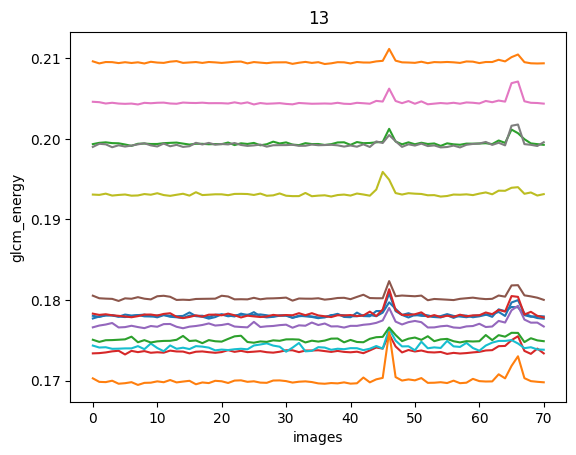

In [15]:
row_sizes = [14, 16, 18, 20, 22, 24, 26, 28, 26, 24, 22, 20, 18, 16, 14]
plt.figure()
for i in range(0, 14):
    plot_baseline_from_feature(i, 'glcm_energy')
plt.show()

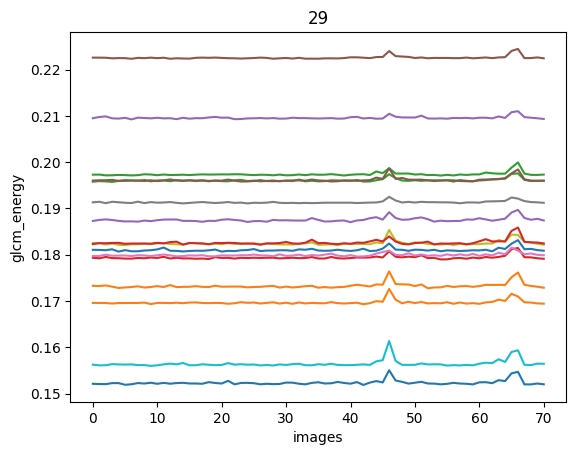

In [16]:
plt.figure()
for i in range(14, 30):
    plot_baseline_from_feature(i, 'glcm_energy')
plt.show()

## Extract features and find annomarly 

In [17]:
def mark_mirrors_on_img(img_path, points_list):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img_rgb)

    for points in points_list:
        # === Polygon na podstawie 4 współrzędnych ===
        polygon = patches.Polygon(
                points,
                closed=True,
                linewidth=2,
                edgecolor='red',
                facecolor='red',
                alpha=0.3  # przezroczystość wypełnienia
            )
        ax.add_patch(polygon)

    plt.tight_layout()
    plt.show()

In [13]:
def extract_features_for_mirror(
        img_gray: np.ndarray,
        mirror_extractor: SimpleMirrorExtractor,
        mirror_id: int,
) -> np.ndarray | None:
    """Extract all featues for a single mirror crop. Return None on failure."""
    try:
        crop = mirror_extractor.extract_mirror_gray(img_gray, mirror_id=mirror_id)
        glcm = extract_glcm_features(crop)
        lbp = extract_lbp_features(crop)
        edge = extract_edge_features(crop)

        vec = np.array(
            [glcm[k] for k in GLCM_KEYS]
            + [lbp[k] for k in LBP_KEYS]
            + [edge[k] for k in EDGE_KEYS],
            dtype=np.float32
        )
        return vec
    except Exception as e:
        print("Mirror %d extrraction failed: %s", mirror_id, e)
        return None

In [21]:
#mirror_extractor = SimpleMirrorExtractor("/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/points_WebCam.json")
#img_path = "/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/MAGIC/webcam_useful_images/image_2024-05-05_1300.jpg"

img_path = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/webcam_useful_image/webcam_useful_images/image_2024-05-05_1300.jpg"
mirror_extractor = SimpleMirrorExtractor("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/calibration/points_WebCam.json")
img = cv2.imread(str(img_path))
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

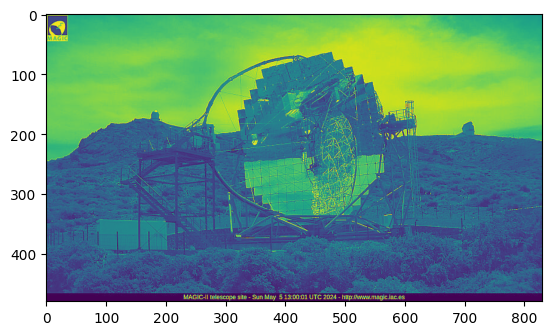

In [22]:
plt.imshow(img_gray)

In [32]:
# Feature keys in guaranteed order
GLCM_KEYS = [
    'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity',
    'glcm_energy', 'glcm_correlation',
]

LBP_KEYS = ['lbp_entropy', 'lbp_uniformity']
EDGE_KEYS = ['sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density']

ALL_FEATURE_KEYS = GLCM_KEYS + LBP_KEYS + EDGE_KEYS

def get_baseline(features):
    baseline_median = np.median(features, axis=0)
    baseline_mad = np.median(
        np.abs(features - baseline_median[np.newaxis, :, :]),
        axis=0
    )*1.4826
    
    #Minum MAD żeby uniknąć dzielenia przez 0
    baseline_mad = np.maximum(baseline_mad, 1e-6)
    
    return baseline_median, baseline_mad
    
def find_outliers(img_gray, mirror_extractor, baseline_median, baseline_mad, key):
    new_features_vec = np.zeros((249, 11))
    for i in range(0, 249):
        new_features_vec[i, :] = extract_features_for_mirror(img_gray, mirror_extractor, i)

    z_from_baseline = (new_features_vec - baseline_median) / baseline_mad
    # 0 -> 'glcm_contrast', 1-> 'glcm_dissimilarity', 2->'glcm_homogeneity'
    print(np.where(z_from_baseline[:, key] > 3.))
    print(np.where(z_from_baseline[:, key] < -3.0))

In [34]:
baseline_median, baseline_mad = get_baseline(features)

find_outliers(img_gray, mirror_extractor, baseline_median, baseline_mad)

In [28]:
baseline_median.shape

(249, 11)

In [36]:
features.shape

(71, 249, 11)

In [2]:
# Feature keys in guaranteed order
GLCM_KEYS = [
    'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity',
    'glcm_energy', 'glcm_correlation',
]
LBP_KEYS = ['lbp_entropy', 'lbp_uniformity']
EDGE_KEYS = ['sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density']
ALL_FEATURE_KEYS = GLCM_KEYS + LBP_KEYS + EDGE_KEYS

In [4]:
FEATURE_IDX = {key: i for i, key in enumerate(ALL_FEATURE_KEYS)}

N_MIRRORS = 249
N_FEATURES = len(ALL_FEATURE_KEYS)

MAD_SCALE = 1.4826  # konsystencja z odchyleniem standardowym przy rozkładzie normalnym
MAD_FLOOR = 1e-6    # zabezpieczenie przed dzieleniem przez 0

In [7]:
@dataclass
class Baseline:
    """Median and scale MAD per (mirros, feature).""" 
    median: np.ndarray # shape (N_MIRRORS, N_FEATURES)
    mad: np.ndarray    # shape (N_MIRRORS, N_FEATURES)

    def z_scores(self, features: np.ndarray) -> np.ndarray:
        """Robust z-score (x - median) / (1.4826*MAD)"""
        return (features - self.median) / self.mad

def get_baseline(features: np.ndarray) -> Baseline:
    """
    Calculate robust baseline from N reference images
    """
    if features.ndim != 3:
        raise ValueError(
            f"Expected 3D array (n_images, n_mirrors, n_features), got shape {features.shape}"
        )
    # nanmedian — odporność na pojedyncze nieudane ekstrakcje
    median = np.nanmedian(features, axis=0)
    mad = np.nanmedian(np.abs(features - median[np.newaxis, :, :]), axis=0) * MAD_SCALE
    mad = np.maximum(mad, MAD_FLOOR)

    return Baseline(median=median, mad=mad)

def extract_all_mirrors(img_gray, mirror_extractor) -> np.ndarray:
    """Ekstrakcja features dla wszystkich luster z jednego obrazu."""
    out = np.full((N_MIRRORS, N_FEATURES), np.nan)
    for i in range(N_MIRRORS):
        out[i, :] = extract_features_for_mirror(img_gray, mirror_extractor, i)
    return out

def find_outliers(
    img_gray,
    mirror_extractor,
    baseline: Baseline,
    threshold: float = 3.0,
    keys: Optional[list[str]] = None,
) -> dict:
    """
    Znajduje outliery w nowym obrazie względem baseline.
    
    Returns:
        dict {feature_key: {'high': array_of_mirror_idx,
                            'low':  array_of_mirror_idx,
                            'z':    array_z_scores_shape_(249,)}}
    """
    if keys is None:
        keys = ALL_FEATURE_KEYS

    new_features = extract_all_mirrors(img_gray, mirror_extractor)
    z = baseline.z_scores(new_features)  # (249, 11)

    results = {}
    for key in keys:
        idx = FEATURE_IDX[key]
        z_col = z[:, idx]
        # nan-safe porównania — NaN nigdy nie spełni warunku
        high = np.where(z_col > threshold)[0]
        low = np.where(z_col < -threshold)[0]
        results[key] = {'high': high, 'low': low, 'z': z_col}

    return results

In [23]:
import numpy as np
from dataclasses import dataclass


@dataclass
class DetectionMetrics:
    tp: int
    fp: int
    fn: int
    precision: float
    recall: float
    f1: float
    iou: float
    
    @property
    def summary(self) -> str:
        return (f"P={self.precision:.3f} R={self.recall:.3f} "
                f"F1={self.f1:.3f} IoU={self.iou:.3f} "
                f"(TP={self.tp}, FP={self.fp}, FN={self.fn})")


def aggregate_outliers(
    outliers: dict,
    strategy: str = 'union',
    min_votes: int = 2,
    n_mirrors: int = 249,
) -> np.ndarray:
    """
    Łączy wyniki z wszystkich features w jedną listę podejrzanych luster.
    
    strategy:
        'union'  — lustro outlier jeśli wykryte przez jakikolwiek feature
        'voting' — lustro outlier jeśli wykryte przez >= min_votes features
    
    Returns: array indeksów luster oznaczonych jako outliers
    """
    votes = np.zeros(n_mirrors, dtype=int)
    for key, res in outliers.items():
        flagged = np.concatenate([res['high'], res['low']])
        votes[flagged] += 1
    
    if strategy == 'union':
        return np.where(votes >= 1)[0]
    elif strategy == 'voting':
        return np.where(votes >= min_votes)[0]
    else:
        raise ValueError(f"Unknown strategy: {strategy}")


def aggregate_score(outliers: dict, n_mirrors: int = 249) -> np.ndarray:
    """
    Score per lustro = max |z| po features. Wyższy score = bardziej podejrzane.
    Daje ranking, nie binarną decyzję.
    """
    scores = np.zeros(n_mirrors)
    for key, res in outliers.items():
        scores = np.maximum(scores, np.abs(res['z']))
    return scores


def compute_metrics(
    predicted: np.ndarray,
    ground_truth: list,
    n_mirrors: int = 249,
) -> DetectionMetrics:
    """Klasyczne P/R/F1/IoU dla detekcji binarnej."""
    pred_set = set(predicted.tolist())
    gt_set = set(ground_truth)
    
    tp = len(pred_set & gt_set)
    fp = len(pred_set - gt_set)
    fn = len(gt_set - pred_set)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)
    
    union = len(pred_set | gt_set)
    iou = tp / union if union > 0 else 0.0
    
    return DetectionMetrics(tp, fp, fn, precision, recall, f1, iou)


def average_precision(scores: np.ndarray, ground_truth: list) -> float:
    """
    AP — metryka rankingowa niezależna od progu.
    Sortuje lustra po score malejąco i liczy pole pod krzywą PR.
    """
    gt_set = set(ground_truth)
    order = np.argsort(-scores)  # malejąco
    
    tp_cum, fp_cum = 0, 0
    precisions, recalls = [], []
    n_gt = len(gt_set)
    
    for mirror_idx in order:
        if mirror_idx in gt_set:
            tp_cum += 1
        else:
            fp_cum += 1
        precisions.append(tp_cum / (tp_cum + fp_cum))
        recalls.append(tp_cum / n_gt if n_gt > 0 else 0.0)
    
    # AP jako suma (R[i] - R[i-1]) * P[i]
    ap = 0.0
    prev_recall = 0.0
    for p, r in zip(precisions, recalls):
        ap += (r - prev_recall) * p
        prev_recall = r
    return ap


def recall_at_k(scores: np.ndarray, ground_truth: list, k: int) -> float:
    """Ile z oznaczonych luster jest w top-k podejrzanych."""
    if not ground_truth:
        return 0.0
    top_k = set(np.argsort(-scores)[:k].tolist())
    return len(top_k & set(ground_truth)) / len(ground_truth)

In [11]:
with h5py.File("/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/baseline/baseline_webcam_features.h5", "r") as f:
    features = f["feature_matrix"][:]        # (n_images, 249, 11)

baseline = get_baseline(features)  # features.shape == (71, 249, 11)

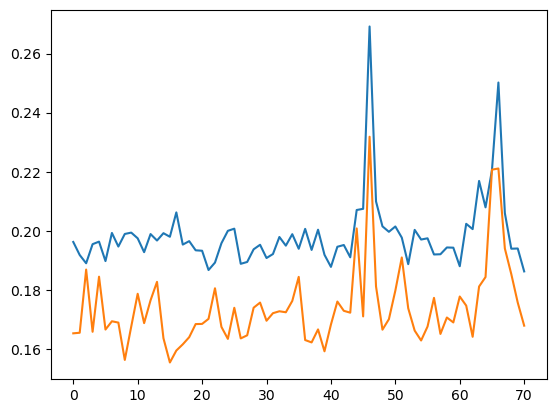

In [60]:

plt.plot(features[:, 10, 2])
plt.plot(features[:, 50, 2])

In [62]:
# Indeksy do usunięcia
indices_to_remove = [46, 65, 66]

# Usunięcie elementów z pierwszego wymiaru
features_filtered = np.delete(features, indices_to_remove, axis=0)

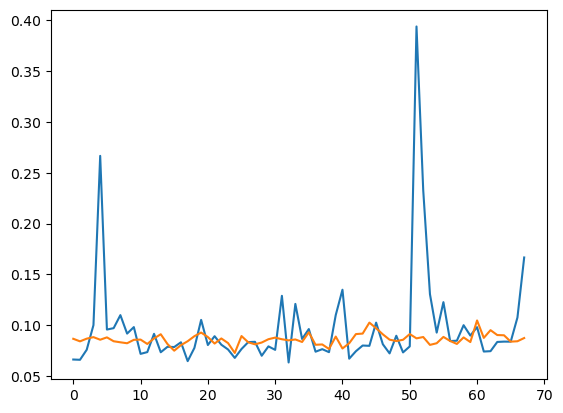

In [76]:
plt.plot(features_filtered[:, 152, 2])
plt.plot(features_filtered[:, 176, 2])

In [64]:
baseline = get_baseline(features_filtered)  # features.shape == (71, 249, 11)

In [72]:
mirror_extractor = SimpleMirrorExtractor("/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/points_WebCam.json")
img_path = "/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/MAGIC/webcam_useful_images/image_2024-05-06_1100.jpg"

#img_path = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/webcam_useful_image/webcam_useful_images/image_2024-05-05_1300.jpg"
#mirror_extractor = SimpleMirrorExtractor("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/calibration/points_WebCam.json")

img = cv2.imread(str(img_path))
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
outliers = find_outliers(
    img_gray, mirror_extractor, baseline, 
    threshold=4.0)  # keys=["glcm_contrast", "laplacian_std"]

In [66]:
# Wszystkie klucze naraz:
for key, res in outliers.items():
    if len(res['high']) or len(res['low']):
        print(f"{key}: high={res['high']}, low={res['low']}")

glcm_contrast: high=[ 19 135 204 243], low=[ 34  36  40  45  46  53  65 101 102 109 112 146 159 160 193 194 208 209
 210]
glcm_dissimilarity: high=[  9 135 152 189 190 204], low=[  8  10  23  25  26  31  32  36  37  44  46  53  60  63  65  69  87  88
 101 102 104 106 109 112 117 123 126 146 159 160 165 193 194 210]
glcm_homogeneity: high=[  0  11  21  25  31  32  33  36  42  43  49  56  63  65  67  69  78  79
  80  84  85  87  88 101 102 103 104 105 119 120 121 122 126 127 166 240], low=[135 190 204 231 232]
glcm_energy: high=[  0  11  19  21  23  24  32  36  43  47  49  56  63  64  65  69  70  78
  79  84  85  87  88  89  90  93  97 101 102 103 104 105 116 117 119 120
 121 122 126 129 149 164 166 198 240 241], low=[231]
glcm_correlation: high=[ 24 172 173 193 217 230 231 232 233], low=[152 176 179 190 192]
lbp_entropy: high=[143 192 210], low=[ 32 152 198]
lbp_uniformity: high=[ 49  85 129], low=[9]
sobel_mean: high=[112], low=[85]
laplacian_mean: high=[ 19 230], low=[ 71 242]
laplaci

In [73]:
ground_truth = [152, 176, 189, 190, 191, 192, 193, 209]

# Strategia 1: union (OR)
pred_union = aggregate_outliers(outliers, strategy='union')
m1 = compute_metrics(pred_union, ground_truth)
print(f"Union:        {m1.summary}")

Union:        P=0.103 R=0.750 F1=0.182 IoU=0.100 (TP=6, FP=52, FN=2)


In [69]:
pred_union

array([  0,   3,   8,   9,  10,  11,  19,  21,  23,  24,  25,  26,  31,
        32,  33,  34,  36,  37,  38,  40,  42,  43,  44,  45,  46,  47,
        48,  49,  53,  56,  59,  60,  63,  64,  65,  67,  69,  70,  71,
        78,  79,  80,  84,  85,  87,  88,  89,  90,  93,  97, 101, 102,
       103, 104, 105, 106, 108, 109, 112, 116, 117, 119, 120, 121, 122,
       123, 126, 127, 128, 129, 135, 136, 143, 146, 149, 152, 159, 160,
       164, 165, 166, 172, 173, 176, 179, 180, 189, 190, 192, 193, 194,
       198, 204, 208, 209, 210, 215, 217, 230, 231, 232, 233, 239, 240,
       241, 242, 243])

In [74]:
# Strategia 2: voting (>= 2 features muszą się zgodzić)
pred_voting = aggregate_outliers(outliers, strategy='voting', min_votes=2)
m2 = compute_metrics(pred_voting, ground_truth)
print(f"Voting (k=2): {m2.summary}")

Voting (k=2): P=0.094 R=0.375 F1=0.150 IoU=0.081 (TP=3, FP=29, FN=5)


In [75]:
# Strategia 3: ranking
scores = aggregate_score(outliers)
ap = average_precision(scores, ground_truth)
r_at_8 = recall_at_k(scores, ground_truth, k=8)
r_at_20 = recall_at_k(scores, ground_truth, k=20)
print(f"AP={ap:.3f}  R@8={r_at_8:.3f}  R@20={r_at_20:.3f}")

AP=0.137  R@8=0.250  R@20=0.375


In [42]:
pred_voting

array([101, 102, 190])

In [43]:
my_pred = np.array([150, 155, 160, 190, 191])
m4 = compute_metrics(my_pred, ground_truth)
print(f"My pred:        {m4.summary}")

My pred:        P=0.400 R=0.250 F1=0.308 IoU=0.182 (TP=2, FP=3, FN=6)


In [46]:
outliers['glcm_contrast']['high']

array([190, 220])

In [47]:
outliers['glcm_contrast']['low']

array([ 32,  47, 101, 102, 109, 160, 193])

In [49]:
np.concatenate([outliers['glcm_contrast']['high'], outliers['glcm_contrast']['low']])

array([190, 220,  32,  47, 101, 102, 109, 160, 193])

In [67]:
for key in outliers.keys():
    print(key)
    pred_array = np.concatenate([outliers[key]['high'], outliers[key]['low']])
    m = compute_metrics(pred_array, ground_truth)
    print(f"{key} pred:        {m.summary}")

glcm_contrast
glcm_contrast pred:        P=0.087 R=0.250 F1=0.129 IoU=0.069 (TP=2, FP=21, FN=6)
glcm_dissimilarity
glcm_dissimilarity pred:        P=0.100 R=0.500 F1=0.167 IoU=0.091 (TP=4, FP=36, FN=4)
glcm_homogeneity
glcm_homogeneity pred:        P=0.024 R=0.125 F1=0.041 IoU=0.021 (TP=1, FP=40, FN=7)
glcm_energy
glcm_energy pred:        P=0.000 R=0.000 F1=0.000 IoU=0.000 (TP=0, FP=47, FN=8)
glcm_correlation
glcm_correlation pred:        P=0.357 R=0.625 F1=0.455 IoU=0.294 (TP=5, FP=9, FN=3)
lbp_entropy
lbp_entropy pred:        P=0.333 R=0.250 F1=0.286 IoU=0.167 (TP=2, FP=4, FN=6)
lbp_uniformity
lbp_uniformity pred:        P=0.000 R=0.000 F1=0.000 IoU=0.000 (TP=0, FP=4, FN=8)
sobel_mean
sobel_mean pred:        P=0.000 R=0.000 F1=0.000 IoU=0.000 (TP=0, FP=2, FN=8)
laplacian_mean
laplacian_mean pred:        P=0.000 R=0.000 F1=0.000 IoU=0.000 (TP=0, FP=4, FN=8)
laplacian_std
laplacian_std pred:        P=0.059 R=0.250 F1=0.095 IoU=0.050 (TP=2, FP=32, FN=6)
edge_density
edge_density pred:  